<a href="https://colab.research.google.com/github/martdbj/PytorchCNNProject/blob/main/InternProjectData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install opendatasets --quiet
# import opendatasets as od
# od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

In [ ]:
import torch
from torch import nn
from torch.optim import Adam # Optimizers
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader # Custom datasets
from sklearn.preprocessing import LabelEncoder # String ot integers
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import os

device = "cpu"
print("Devices avaialable:", device)

Devices avaialable: cpu


In [ ]:
import os
import pandas as pd

base_path = '/content/workFolder/afhq'
image_path = []
labels = []

# The dataset is organized as: afhq / [train|val] / [cat|dog|wild] / image.jpg
for split in ['train', 'val']:
    split_path = os.path.join(base_path, split)
    if os.path.exists(split_path):
        for label_dir in os.listdir(split_path):
            category_path = os.path.join(split_path, label_dir)

            # Ensure we are looking at a category directory and skip hidden files
            if os.path.isdir(category_path) and not label_dir.startswith('.'):
                for image_file in os.listdir(category_path):
                    if image_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        full_image_path = os.path.join(category_path, image_file)
                        image_path.append(full_image_path)
                        labels.append(label_dir) # Use the animal category as the label

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])

print("Unique labels found:", data_df["labels"].unique())
print(f"Total images loaded: {len(data_df)}")
display(data_df.head())

Unique labels found: ['lion' 'horse' 'cat']
Total images loaded: 720


,image_path,labels
0,/content/workFolder/afhq/train/lion/lion106.jpg,lion
1,/content/workFolder/afhq/train/lion/lion82.jpg,lion
2,/content/workFolder/afhq/train/lion/lion24.jpg,lion
3,/content/workFolder/afhq/train/lion/lion40.jpg,lion
4,/content/workFolder/afhq/train/lion/lion71.jpg,lion


In [ ]:
import os

def list_structure(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files[:3]: # Show only first 3 files
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...')

print('Structure of /content/workFolder/afhq:')
if os.path.exists('/content/workFolder/afhq'):
    list_structure('/content/workFolder/afhq')
else:
    print('Path does not exist.')

print('\nStructure of /content/animal-faces:')
if os.path.exists('/content/animal-faces'):
    list_structure('/content/animal-faces')
else:
    print('Path does not exist.')

Structure of /content/workFolder/afhq:
afhq/
    .ipynb_checkpoints/
    train/
        .ipynb_checkpoints/
        lion/
            lion106.jpg
            lion82.jpg
            lion24.jpg
            ...
        horse/
            horse106.jpg
            horse100.jpg
            horse99.jpg
            ...
        cat/
            cat91.jpg
            cat120.jpg
            cat2.jpg
            ...
    val/
        .ipynb_checkpoints/
        lion/
            lion24.jpg
            lion40.jpg
            lion14.jpg
            ...
        horse/
            horse9.png
            horse28.png
            horse34.png
            ...
        cat/
            cat2.jpg
            cat23.jpg
            cat7.jpg
            ...

Structure of /content/animal-faces:
animal-faces/
    afhq/
        train/
            .ipynb_checkpoints/
            lion/
                flickr_wild_001703.jpg
                flickr_wild_002680.jpg
                flickr_wild_002221.jpg
                ..

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and a temporary set (validation + test)
train_df, temp_df = train_test_split(data_df, test_size=0.3, random_state=42, stratify=data_df['labels'])

# Split the temporary set into validation and test sets
# We want val and test to be 15% each, so test_size=0.5 splits temp_df (which is 30% of original) evenly
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['labels'])

train = train_df # Renaming for consistency with original notebook's variable names
val = val_df
test = test_df

print(f"Train set size: {len(train)}")
print(f"Validation set size: {len(val)}")
print(f"Test set size: {len(test)}")

print("\nTrain labels distribution:")
display(train['labels'].value_counts(normalize=True))
print("\nValidation labels distribution:")
display(val['labels'].value_counts(normalize=True))
print("\nTest labels distribution:")
display(test['labels'].value_counts(normalize=True))

Train set size: 504
Validation set size: 108
Test set size: 108

Train labels distribution:


,proportion
labels,
lion,0.333333
horse,0.333333
cat,0.333333



Validation labels distribution:


,proportion
labels,
cat,0.333333
lion,0.333333
horse,0.333333



Test labels distribution:


,proportion
labels,
lion,0.333333
horse,0.333333
cat,0.333333


In [ ]:
label_enconder = LabelEncoder()
label_enconder.fit(data_df["labels"])

transform = transforms.Compose([ # All the images will have the same properties
    transforms.Resize((129, 129)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataSet(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.lables = torch.tensor(label_enconder.transform(dataframe["labels"]))

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, index):
    image_path = self.dataframe.iloc[index, 0]
    label = self.lables[index]

    image = Image.open(image_path).convert('RGB')

    if self.transform:
      image = self.transform(image)

    return image, label

In [ ]:
train_dataset = CustomImageDataSet(dataframe = train, transform = transform)
val_dataset = CustomImageDataSet(dataframe = val, transform = transform)
test_dataset = CustomImageDataSet(dataframe = test, transform = transform)

In [ ]:
# # Visualize the images
# n_rows = 3
# n_cols = 3

# f, axarr = plt.subplots(n_rows, n_cols)

# for row in range(n_rows):
#   for col in range(n_cols):
#     image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert('RGB')
#     axarr[row, col].imshow(image)
#     axarr[row, col].axis('off')

# plt.show()

In [ ]:
LR = 1e-3
BATCH_SIZE = 64
EPOCHS = 12

In [ ]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    # Convolution layers with padding=1 to keep dimensions consistent before pooling
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()

    self.linear = nn.Linear((128 * 16 * 16), 128) # Updated input size
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.relu(self.pooling(self.conv1(x)))
    x = self.relu(self.pooling(self.conv2(x)))
    x = self.relu(self.pooling(self.conv3(x)))

    x = self.flatten(x)
    x = self.relu(self.linear(x))
    x = self.output(x)
    return x

In [ ]:
model = Net().to(device) # We have to move everything to the CUDA device

In [ ]:
from torchsummary import summary
# Re-initialize model to apply changes
model = Net().to(device)
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
             ReLU-12                  [-1, 128]               0
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train()
  for inputs, labels in train_loader:
    # Move data to the same device as the model
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()

    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc

    optimizer.step()

  model.eval()
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      v_loss = criterion(outputs, labels)
      total_loss_val += v_loss.item()

      val_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
      total_acc_val += val_acc

  # Logging results
  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss = total_loss_val / len(val_loader)
  train_accuracy = (total_acc_train / len(train_dataset)) * 100
  val_accuracy = (total_acc_val / len(val_dataset)) * 100

  total_loss_train_plot.append(avg_train_loss)
  total_loss_val_plot.append(avg_val_loss)
  total_acc_train_plot.append(train_accuracy)
  total_acc_validation_plot.append(val_accuracy)

  print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f} Train Accuracy: {train_accuracy:.2f}%\n" \
        f"        Validation Loss: {avg_val_loss:.4f} Validation Accuracy: {val_accuracy:.2f}%\n")

Epoch 1, Train Loss: 1.1103 Train Accuracy: 33.93%
        Validation Loss: 1.0451 Validation Accuracy: 38.89%

Epoch 2, Train Loss: 1.0294 Train Accuracy: 52.58%
        Validation Loss: 0.8862 Validation Accuracy: 59.26%

Epoch 3, Train Loss: 0.9444 Train Accuracy: 59.33%
        Validation Loss: 0.8168 Validation Accuracy: 61.11%

Epoch 4, Train Loss: 0.7767 Train Accuracy: 67.46%
        Validation Loss: 0.6870 Validation Accuracy: 71.30%

Epoch 5, Train Loss: 0.6348 Train Accuracy: 74.60%
        Validation Loss: 0.7224 Validation Accuracy: 70.37%

Epoch 6, Train Loss: 0.5125 Train Accuracy: 79.56%
        Validation Loss: 0.6703 Validation Accuracy: 69.44%

Epoch 7, Train Loss: 0.4816 Train Accuracy: 81.75%
        Validation Loss: 0.4748 Validation Accuracy: 81.48%

Epoch 8, Train Loss: 0.3664 Train Accuracy: 86.51%
        Validation Loss: 0.6113 Validation Accuracy: 71.30%

Epoch 9, Train Loss: 0.3677 Train Accuracy: 86.11%
        Validation Loss: 0.4815 Validation Accuracy: 

In [ ]:
# Testing
model.eval()
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
    total_acc_test += acc

    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

final_acc = (total_acc_test / len(test_dataset)) * 100
avg_loss = total_loss_test / len(test_loader)
print(f"Accuracy Score: {final_acc}% and Average Loss is {avg_loss}")

Accuracy Score: 79.62962962962963% and Average Loss is 0.4812241941690445


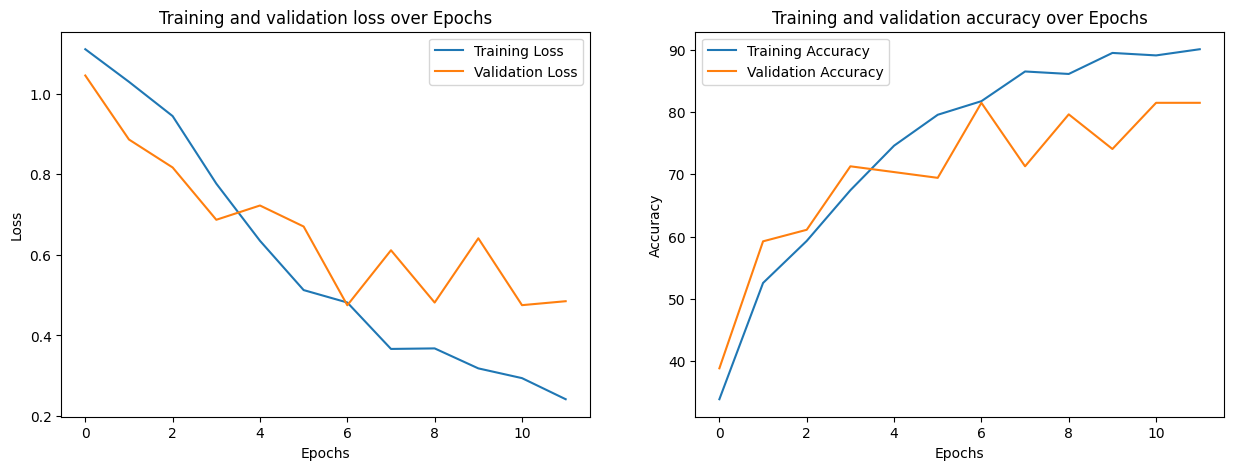

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

# Plot Loss
axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Training and validation loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

# Plot Accuracy
axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and validation accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
#1 - Read image
#2 - Transform using transform object
#3 - Predict through the model
#4 - Inverse transform by label encoder

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  model.eval()
  with torch.no_grad():
    output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis = 1).item()
    output = label_enconder.inverse_transform([output])
  return output

cat_folder = "/content/cat"
cat_images = os.listdir(cat_folder)

print("Cat image test")
for cat_file in cat_images:
  full_path = os.path.join(cat_folder, cat_file)
  print(f"{cat_file}: {predict_image(full_path)}")

lion_folder = "/content/lion"
lion_images = os.listdir(lion_folder)

print("\nLion image test")
for lion_file in lion_images:
  full_path = os.path.join(lion_folder, lion_file)
  print(f"{lion_file}: {predict_image(full_path)}")

horse_folder = "/content/horse"
horse_images = os.listdir(horse_folder)

print("\nHorse image test")
for horse_file in horse_images:
  full_path = os.path.join(horse_folder, horse_file)
  print(f"{horse_file}: {predict_image(full_path)}")

Cat image test
cat1664.jpg: ['cat']
cat1673.jpg: ['cat']
cat1659.jpg: ['lion']
cat1663.jpg: ['cat']
cat1667.jpg: ['cat']
cat1665.jpg: ['lion']
cat1674.jpg: ['cat']
cat1671.jpg: ['cat']
cat.jpg: ['lion']
cat1676.jpg: ['cat']
cat1660.jpg: ['cat']
cat1666.jpg: ['cat']
cat1657.jpg: ['horse']
cat1661.jpg: ['cat']
cat1677.jpg: ['cat']
cat1669.jpg: ['cat']
cat1672.jpg: ['cat']
cat1670.jpg: ['cat']
cat1658.jpg: ['cat']
cat1662.jpg: ['cat']
cat1675.jpg: ['cat']
cat1668.jpg: ['cat']

Lion image test
lion2156.jpg: ['lion']
lion2139.jpg: ['lion']
lion2167.jpg: ['horse']
lion2179.jpg: ['cat']
lion2134.jpg: ['horse']
lion2171.jpg: ['lion']
lion2162.jpg: ['lion']
lion2135.jpg: ['horse']
lion2169.jpg: ['lion']
lion2129.jpg: ['horse']
lion2161.jpg: ['lion']
lion2150.jpg: ['horse']
lion.jpg: ['lion']
lion2128.jpg: ['lion']
lion2155.jpg: ['horse']
lion2118.jpg: ['lion']
lion2172.jpg: ['horse']
lion2164.jpg: ['horse']
lion2149.jpg: ['lion']
lion2148.jpg: ['lion']
lion2120.jpg: ['lion']
lion2157.jpg: ['hor